# Assignment 2 - Improved NLP Models for IMDB Sentiment Analysis
This notebook improves Assignment 1 by replacing handcrafted sentiment features with deep learning models trained directly on review text.

In [1]:
import os
import re
import csv
import json
import math
import time
import random
import tarfile
import urllib.request
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


## What changed from Assignment 1
- Removed VADER/TextBlob handcrafted features.
- Built a text pipeline using tokenization, vocabulary, integer encoding, and padding.
- Added **three models**: 1D CNN, BiLSTM, and BiGRU.
- Added optimization techniques: dropout, weight decay, gradient clipping, early stopping, and learning-rate scheduling.
- Saved a separate `results.txt` and `README.md` for every model.

In [2]:
# Configuration
DATASET_URL = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
TAR_PATH = "aclImdb_v1.tar.gz"
EXTRACT_DIR = "aclImdb"

MAX_VOCAB_SIZE = 20000
MAX_LEN = 250
BATCH_SIZE = 128
EPOCHS = 8
PATIENCE = 2
MIN_FREQ = 2

# Set to a smaller number like 10000 for quick experiments.
SAMPLE_SIZE = None

OUTPUT_DIR = "assignment2_imdb_models"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [3]:
def download_and_extract_imdb():
    if not os.path.exists(TAR_PATH):
        print("Downloading IMDB dataset...")
        urllib.request.urlretrieve(DATASET_URL, TAR_PATH)
        print("Download complete.")
    else:
        print("Dataset archive already exists.")

    if not os.path.exists(EXTRACT_DIR):
        print("Extracting dataset...")
        with tarfile.open(TAR_PATH, "r:gz") as tar:
            tar.extractall()
        print("Extraction complete.")
    else:
        print("Dataset already extracted.")

download_and_extract_imdb()

Download complete.
Extracting dataset...


/tmp/ipykernel_8476/3920363754.py:12: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


Extraction complete.


In [4]:
def load_reviews(data_path="aclImdb", split="train"):
    reviews = []
    labels = []

    split_path = os.path.join(data_path, split)
    for sentiment, label in [("pos", 1), ("neg", 0)]:
        sentiment_path = os.path.join(split_path, sentiment)
        files = sorted(os.listdir(sentiment_path))

        for filename in files:
            if filename.endswith(".txt"):
                file_path = os.path.join(sentiment_path, filename)
                with open(file_path, "r", encoding="utf-8") as f:
                    reviews.append(f.read())
                    labels.append(label)

    return reviews, labels

train_reviews, train_labels = load_reviews(split="train")
test_reviews, test_labels = load_reviews(split="test")

if SAMPLE_SIZE is not None:
    train_reviews = train_reviews[:SAMPLE_SIZE]
    train_labels = train_labels[:SAMPLE_SIZE]
    test_reviews = test_reviews[:SAMPLE_SIZE]
    test_labels = test_labels[:SAMPLE_SIZE]

print("Train size:", len(train_reviews))
print("Test size:", len(test_reviews))

Train size: 25000
Test size: 25000


In [5]:
def simple_tokenize(text):
    text = text.lower()
    text = re.sub(r"<br\s*/?>", " ", text)
    return re.findall(r"[a-z']+", text)

def build_vocab(texts, max_vocab_size=20000, min_freq=2):
    counter = Counter()
    for text in texts:
        counter.update(simple_tokenize(text))

    vocab = {"<PAD>": 0, "<UNK>": 1}
    for token, freq in counter.most_common():
        if freq < min_freq:
            continue
        if len(vocab) >= max_vocab_size:
            break
        vocab[token] = len(vocab)

    return vocab

def encode_text(text, vocab, max_len=250):
    tokens = simple_tokenize(text)
    ids = [vocab.get(tok, vocab["<UNK>"]) for tok in tokens[:max_len]]
    if len(ids) < max_len:
        ids += [vocab["<PAD>"]] * (max_len - len(ids))
    return ids

vocab = build_vocab(train_reviews, MAX_VOCAB_SIZE, MIN_FREQ)
print("Vocabulary size:", len(vocab))

Vocabulary size: 20000


In [6]:
X_train_texts, X_val_texts, y_train, y_val = train_test_split(
    train_reviews,
    train_labels,
    test_size=0.2,
    random_state=SEED,
    stratify=train_labels
)

print("Train split:", len(X_train_texts))
print("Validation split:", len(X_val_texts))
print("Test split:", len(test_reviews))

Train split: 20000
Validation split: 5000
Test split: 25000


In [7]:
class IMDBDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len):
        self.encoded = [encode_text(text, vocab, max_len) for text in texts]
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = torch.tensor(self.encoded[idx], dtype=torch.long)
        y = torch.tensor(self.labels[idx], dtype=torch.float32)
        return x, y

train_dataset = IMDBDataset(X_train_texts, y_train, vocab, MAX_LEN)
val_dataset = IMDBDataset(X_val_texts, y_val, vocab, MAX_LEN)
test_dataset = IMDBDataset(test_reviews, test_labels, vocab, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Batches - train:", len(train_loader), "val:", len(val_loader), "test:", len(test_loader))

Batches - train: 157 val: 40 test: 196


In [8]:
class CNN1DClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, num_filters=128, kernel_sizes=(3, 4, 5), dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embed_dim, out_channels=num_filters, kernel_size=k)
            for k in kernel_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), 1)

    def forward(self, x):
        embedded = self.embedding(x)                  # [B, L, E]
        embedded = embedded.transpose(1, 2)          # [B, E, L]
        conv_features = [torch.relu(conv(embedded)).max(dim=2).values for conv in self.convs]
        combined = torch.cat(conv_features, dim=1)
        output = self.fc(self.dropout(combined))
        return output.squeeze(1)

class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, num_layers=2, dropout=0.4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        embedded = self.embedding(x)
        _, (hidden, _) = self.lstm(embedded)
        forward_hidden = hidden[-2]
        backward_hidden = hidden[-1]
        combined = torch.cat([forward_hidden, backward_hidden], dim=1)
        output = self.fc(self.dropout(combined))
        return output.squeeze(1)

class BiGRUClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, num_layers=2, dropout=0.4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.gru = nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        embedded = self.embedding(x)
        _, hidden = self.gru(embedded)
        forward_hidden = hidden[-2]
        backward_hidden = hidden[-1]
        combined = torch.cat([forward_hidden, backward_hidden], dim=1)
        output = self.fc(self.dropout(combined))
        return output.squeeze(1)

In [9]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

dummy_batch = next(iter(train_loader))[0][:4].to(DEVICE)

for name, model in {
    "cnn_1d": CNN1DClassifier(len(vocab)),
    "bilstm": BiLSTMClassifier(len(vocab)),
    "bigru": BiGRUClassifier(len(vocab)),
}.items():
    model = model.to(DEVICE)
    with torch.no_grad():
        logits = model(dummy_batch)
    print(f"{name}: parameters={count_parameters(model):,}, output_shape={tuple(logits.shape)}")

cnn_1d: parameters=2,757,377, output_shape=(4,)
bilstm: parameters=3,219,713, output_shape=(4,)
bigru: parameters=3,054,849, output_shape=(4,)


In [10]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    all_preds = []
    all_labels = []

    for x_batch, y_batch in loader:
        x_batch = x_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()
        logits = model(x_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * x_batch.size(0)
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).long()

        all_preds.extend(preds.cpu().numpy().tolist())
        all_labels.extend(y_batch.long().cpu().numpy().tolist())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_probs = []
    all_labels = []

    for x_batch, y_batch in loader:
        x_batch = x_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        logits = model(x_batch)
        loss = criterion(logits, y_batch)

        total_loss += loss.item() * x_batch.size(0)
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).long()

        all_probs.extend(probs.cpu().numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())
        all_labels.extend(y_batch.long().cpu().numpy().tolist())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)

    return {
        "loss": avg_loss,
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "labels": all_labels,
        "preds": all_preds,
        "probs": all_probs,
    }

def save_text(path, text):
    with open(path, "w", encoding="utf-8") as f:
        f.write(text)

In [11]:
def train_model(model_name, model, config):
    model_dir = os.path.join(OUTPUT_DIR, model_name)
    os.makedirs(model_dir, exist_ok=True)

    model = model.to(DEVICE)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"]
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=1
    )

    history = []
    best_val_acc = 0.0
    best_state_dict = None
    best_epoch = 0
    patience_counter = 0

    for epoch in range(1, config["epochs"] + 1):
        start_time = time.time()

        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_metrics = evaluate(model, val_loader, criterion)

        scheduler.step(val_metrics["accuracy"])

        current_lr = optimizer.param_groups[0]["lr"]
        epoch_time = time.time() - start_time

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_acc,
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_precision": val_metrics["precision"],
            "val_recall": val_metrics["recall"],
            "val_f1": val_metrics["f1"],
            "lr": current_lr,
            "epoch_time_sec": epoch_time,
        })

        print(
            f"[{model_name}] Epoch {epoch}/{config['epochs']} | "
            f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | val_acc={val_metrics['accuracy']:.4f} | "
            f"lr={current_lr:.6f}"
        )

        if val_metrics["accuracy"] > best_val_acc:
            best_val_acc = val_metrics["accuracy"]
            best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            best_epoch = epoch
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= config["patience"]:
            print(f"Early stopping triggered for {model_name}.")
            break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    torch.save(model.state_dict(), os.path.join(model_dir, "best_model.pt"))

    history_df = pd.DataFrame(history)
    history_df.to_csv(os.path.join(model_dir, "history.csv"), index=False)

    test_metrics = evaluate(model, test_loader, criterion)
    cm = confusion_matrix(test_metrics["labels"], test_metrics["preds"])
    cm_df = pd.DataFrame(cm, index=["Actual_0", "Actual_1"], columns=["Pred_0", "Pred_1"])
    cm_df.to_csv(os.path.join(model_dir, "confusion_matrix.csv"))

    report = classification_report(test_metrics["labels"], test_metrics["preds"], digits=4)
    results_text = f"""Model: {model_name}
Best validation accuracy: {best_val_acc:.4f}
Best epoch: {best_epoch}
Test accuracy: {test_metrics['accuracy']:.4f}
Test precision: {test_metrics['precision']:.4f}
Test recall: {test_metrics['recall']:.4f}
Test F1-score: {test_metrics['f1']:.4f}

Classification Report
---------------------
{report}
"""
    save_text(os.path.join(model_dir, "results.txt"), results_text)

    readme_text = f"""# {model_name}

## Model architecture
{config['architecture_description']}

## Techniques applied
- Tokenization + vocabulary building from training data
- Integer encoding + fixed-length padding (MAX_LEN={MAX_LEN})
- Dropout for regularization
- Adam optimizer
- Weight decay (L2 regularization)
- Gradient clipping
- ReduceLROnPlateau learning-rate scheduling
- Early stopping
- Hyperparameter tuning by changing hidden size / filters / dropout / learning rate

## Training configuration
- Batch size: {BATCH_SIZE}
- Epochs (max): {config['epochs']}
- Learning rate: {config['lr']}
- Weight decay: {config['weight_decay']}
- Patience: {config['patience']}
"""
    save_text(os.path.join(model_dir, "README.md"), readme_text)

    result_row = {
        "model": model_name,
        "best_val_accuracy": best_val_acc,
        "best_epoch": best_epoch,
        "test_accuracy": test_metrics["accuracy"],
        "test_precision": test_metrics["precision"],
        "test_recall": test_metrics["recall"],
        "test_f1": test_metrics["f1"],
        "num_parameters": count_parameters(model),
    }

    return result_row, history_df

In [12]:
model_configs = {
    "cnn_1d": {
        "builder": lambda: CNN1DClassifier(len(vocab), embed_dim=128, num_filters=128, kernel_sizes=(3, 4, 5), dropout=0.5),
        "lr": 1e-3,
        "weight_decay": 1e-4,
        "epochs": EPOCHS,
        "patience": PATIENCE,
        "architecture_description": "Embedding -> Conv1D(3,4,5) -> Global Max Pooling -> Dropout -> Dense(1)"
    },
    "bilstm": {
        "builder": lambda: BiLSTMClassifier(len(vocab), embed_dim=128, hidden_dim=128, num_layers=2, dropout=0.4),
        "lr": 1e-3,
        "weight_decay": 1e-4,
        "epochs": EPOCHS,
        "patience": PATIENCE,
        "architecture_description": "Embedding -> 2-layer Bidirectional LSTM -> Dropout -> Dense(1)"
    },
    "bigru": {
        "builder": lambda: BiGRUClassifier(len(vocab), embed_dim=128, hidden_dim=128, num_layers=2, dropout=0.4),
        "lr": 1e-3,
        "weight_decay": 1e-4,
        "epochs": EPOCHS,
        "patience": PATIENCE,
        "architecture_description": "Embedding -> 2-layer Bidirectional GRU -> Dropout -> Dense(1)"
    },
}

In [13]:
all_results = []
all_histories = {}

for model_name, config in model_configs.items():
    print("\n" + "=" * 80)
    print(f"Training {model_name}")
    print("=" * 80)
    model = config["builder"]()
    result_row, history_df = train_model(model_name, model, config)
    all_results.append(result_row)
    all_histories[model_name] = history_df

results_df = pd.DataFrame(all_results).sort_values(by="test_accuracy", ascending=False).reset_index(drop=True)
results_df.to_csv(os.path.join(OUTPUT_DIR, "all_model_results.csv"), index=False)
results_df


Training cnn_1d
[cnn_1d] Epoch 1/8 | train_loss=0.6679 | train_acc=0.6087 | val_loss=0.5114 | val_acc=0.7648 | lr=0.001000
[cnn_1d] Epoch 2/8 | train_loss=0.5088 | train_acc=0.7457 | val_loss=0.4466 | val_acc=0.7998 | lr=0.001000
[cnn_1d] Epoch 3/8 | train_loss=0.4520 | train_acc=0.7840 | val_loss=0.4477 | val_acc=0.7818 | lr=0.001000
[cnn_1d] Epoch 4/8 | train_loss=0.4173 | train_acc=0.8066 | val_loss=0.3965 | val_acc=0.8196 | lr=0.001000
[cnn_1d] Epoch 5/8 | train_loss=0.3795 | train_acc=0.8278 | val_loss=0.3984 | val_acc=0.8104 | lr=0.001000
[cnn_1d] Epoch 6/8 | train_loss=0.3448 | train_acc=0.8488 | val_loss=0.3683 | val_acc=0.8350 | lr=0.001000
[cnn_1d] Epoch 7/8 | train_loss=0.3108 | train_acc=0.8678 | val_loss=0.3582 | val_acc=0.8354 | lr=0.001000
[cnn_1d] Epoch 8/8 | train_loss=0.2726 | train_acc=0.8885 | val_loss=0.3435 | val_acc=0.8470 | lr=0.001000

Training bilstm
[bilstm] Epoch 1/8 | train_loss=0.6639 | train_acc=0.5857 | val_loss=0.6564 | val_acc=0.6068 | lr=0.001000
[bi

,model,best_val_accuracy,best_epoch,test_accuracy,test_precision,test_recall,test_f1,num_parameters
0,bigru,0.8492,8,0.85696,0.828911,0.89960,0.862810,3054849
1,cnn_1d,0.8470,8,0.85624,0.839302,0.88120,0.859741,2757377
2,bilstm,0.8094,8,0.80488,0.838395,0.75536,0.794714,3219713


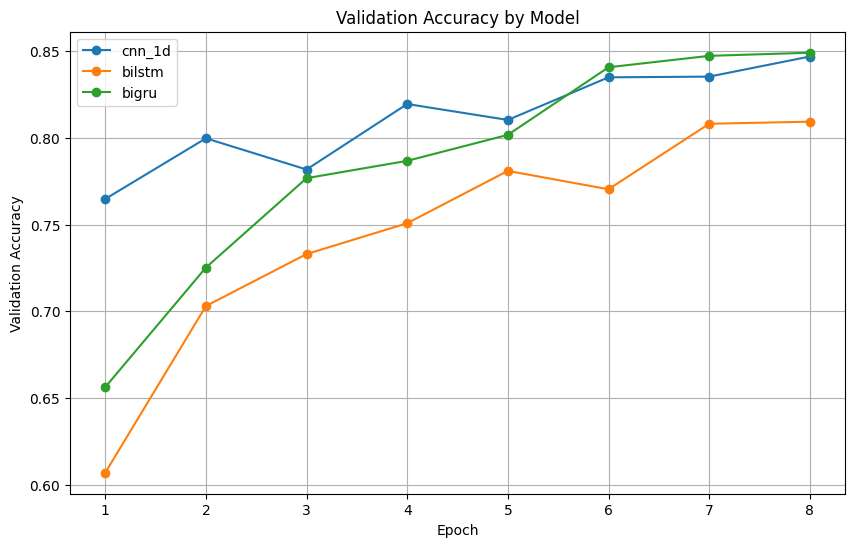

In [14]:
# Plot validation accuracy comparison
plt.figure(figsize=(10, 6))
for model_name, history_df in all_histories.items():
    plt.plot(history_df["epoch"], history_df["val_accuracy"], marker="o", label=model_name)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy by Model")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
best_model_name = results_df.iloc[0]["model"]
print("Best model:", best_model_name)
print("Results saved in:", OUTPUT_DIR)

Best model: bigru
Results saved in: assignment2_imdb_models
